In [6]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import sklearn
import tensorflow as tf



from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras import models # type: ignore
from tensorflow.keras import layers # type: ignore
from tensorflow.keras import optimizers # type: ignore
from tensorflow.keras import callbacks # type: ignore
from tensorflow.keras.models import load_model # type: ignore
from tensorflow.keras import regularizers #type: ignore

In [7]:
x = np.arange(-10,10,0.1)
y = 2*x**2 + 3*x + 7

y_val = y + 100*np.random.rand(len(x))


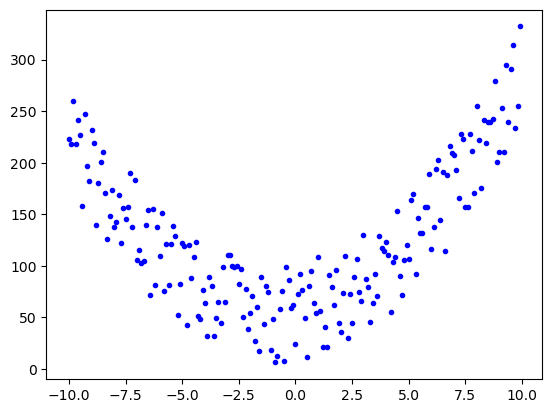

In [8]:
plt.plot(x, y_val, "b.")
plt.show()

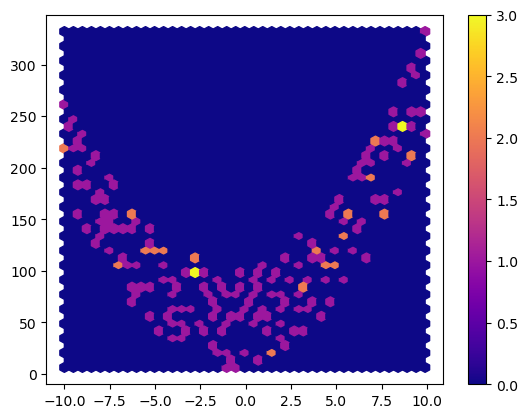

In [9]:
plt.hexbin(x, y_val, cmap = "plasma", gridsize=40, alpha=1)
plt.colorbar()
plt.show()

In [10]:
X_learn, X_test, Y_learn, Y_test = train_test_split(x, y_val, test_size=0.1)

X_learn = X_learn.reshape(-1,1)
X_test = X_test.reshape(-1,1)

In [11]:
model = LinearRegression()
model.fit(X_learn, Y_learn)

y_pred = model.predict(X_test)

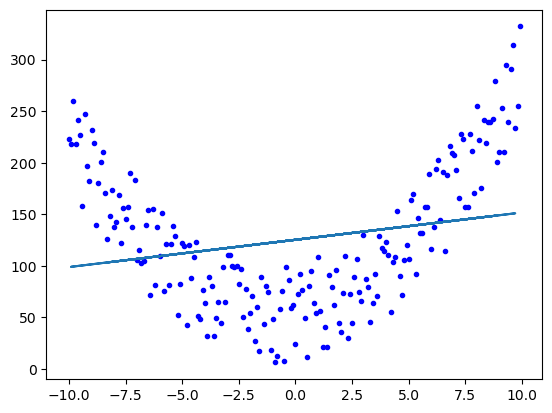

In [12]:
plt.plot(x, y_val, "b.")
plt.plot(X_test, y_pred)
plt.show()

In [13]:
poly = PolynomialFeatures(degree=2)
X_learn_poly = poly.fit_transform(X_learn)
X_test_poly = poly.transform(X_test)

In [14]:
model.fit(X_learn_poly, Y_learn)
y_pred2 = model.predict(X_test_poly)



In [15]:
soreq_id = np.argsort(X_test, axis = 0).reshape(-1)
print(soreq_id)

[ 7 10 17  3  4  2 12 19 14 16 11  9  0 18  8  6  1 15 13  5]


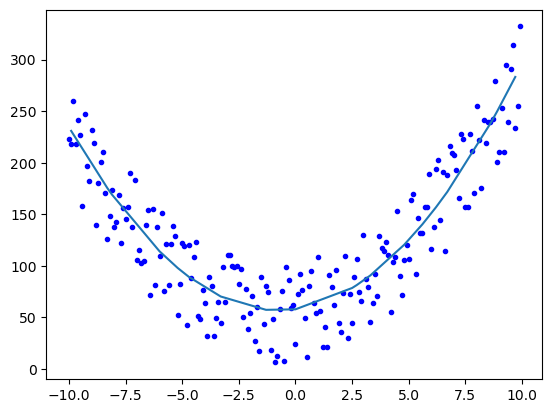

In [16]:



plt.plot(x, y_val, "b.")
plt.plot(X_test[soreq_id], y_pred2[soreq_id])
plt.show()

In [17]:
model.coef_

array([0.        , 3.08232306, 2.07599498])

In [18]:
model = models.Sequential()
model.add(layers.Dense(32, activation="relu"))
model.add(layers.Dense(16, activation="relu"))
model.add(layers.Dense(8, activation="relu"))
model.add(layers.Dense(1, activation= "linear"))

In [23]:
model.compile(optimizer = "adam", loss = "mse", metrics=["mse", "r2_score"] )
callbacks_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=20)
]

model_res = model.fit(X_learn,Y_learn, epochs=100, batch_size= 16, callbacks = callbacks_list  )

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 949.1389 - mse: 949.1389 - r2_score: 0.8024 - learning_rate: 0.0010
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 951.3423 - mse: 951.3423 - r2_score: 0.8020 - learning_rate: 0.0010
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 942.1832 - mse: 942.1832 - r2_score: 0.8039 - learning_rate: 0.0010
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 941.1427 - mse: 941.1427 - r2_score: 0.8041 - learning_rate: 0.0010
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 942.9561 - mse: 942.9561 - r2_score: 0.8037 - learning_rate: 0.0010
Epoch 6/100
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 902.4889 - mse: 902.4889 - r2_score: 0.8644

/home/ivankorolev/anaconda3/envs/envForML/lib/python3.12/site-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,mse,r2_score
  current = self.get_monitor_value(logs)
/home/ivankorolev/anaconda3/envs/envForML/lib/python3.12/site-packages/keras/src/callbacks/callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: loss,mse,r2_score,learning_rate.
  callback.on_epoch_end(epoch, logs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 941.4059 - mse: 941.4059 - r2_score: 0.8040 - learning_rate: 0.0010
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 943.2596 - mse: 943.2596 - r2_score: 0.8036 - learning_rate: 0.0010
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 937.6483 - mse: 937.6483 - r2_score: 0.8048 - learning_rate: 0.0010
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 936.2646 - mse: 936.2646 - r2_score: 0.8051 - learning_rate: 0.0010
Epoch 10/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 941.8158 - mse: 941.8158 - r2_score: 0.8039 - learning_rate: 0.0010
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 942.8403 - mse: 942.8403 - r2_score: 0.8037 - learning_rate: 0.0010
Epoch 12/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 942.9695 - mse: 942.9695 - r2_score: 0.8037 - learning_rate: 0.0010
Epoch 13/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 938.1014 - mse: 938.1014 - r2_score: 0.8047 - learning_rate:

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


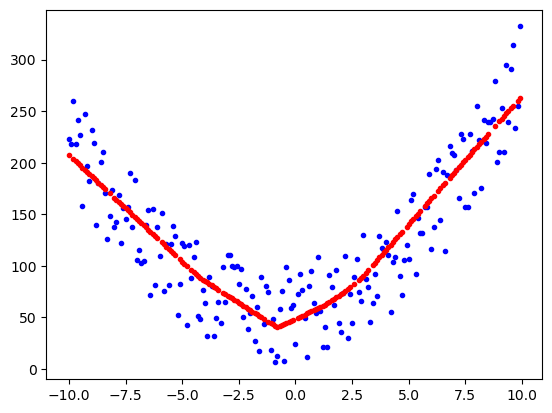

In [34]:
y_pred = model.predict(X_learn)

plt.plot(x, y_val, "b.")
plt.plot(X_learn, y_pred, "r.")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


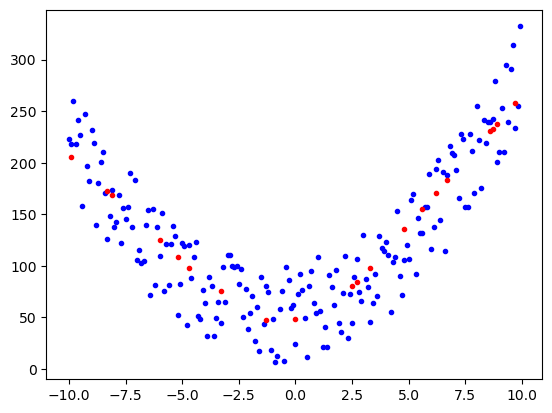

In [35]:
y_pred = model.predict(X_test)

plt.plot(x, y_val, "b.")
plt.plot(X_test, y_pred, "r.")
plt.show()

